In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score, r2_score


# Read CSV

In [3]:
data = pd.read_csv('Store_CA.csv')
data.head()

,ProductVariety,MarketingSpend,CustomerFootfall,StoreSize,EmployeeEfficiency,StoreAge,CompetitorDistance,PromotionsCount,EconomicIndicator,StoreLocation,StoreCategory,MonthlySalesRevenue
0,581,29,1723,186,84.9,1,12,6,108.3,Los Angeles,Electronics,284.90
1,382,31,1218,427,75.8,18,11,6,97.8,Los Angeles,Electronics,308.21
2,449,35,2654,142,92.8,14,11,6,101.1,Los Angeles,Grocery,292.11
3,666,9,2591,159,66.3,11,11,4,115.1,Sacramento,Clothing,279.61
4,657,35,2151,275,89.1,28,12,7,93.4,Palo Alto,Electronics,359.71


## Check Column

In [4]:
data.shape

(1650, 12)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1650 entries, 0 to 1649
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ProductVariety       1650 non-null   int64  
 1   MarketingSpend       1650 non-null   int64  
 2   CustomerFootfall     1650 non-null   int64  
 3   StoreSize            1650 non-null   int64  
 4   EmployeeEfficiency   1650 non-null   float64
 5   StoreAge             1650 non-null   int64  
 6   CompetitorDistance   1650 non-null   int64  
 7   PromotionsCount      1650 non-null   int64  
 8   EconomicIndicator    1650 non-null   float64
 9   StoreLocation        1650 non-null   object 
 10  StoreCategory        1650 non-null   object 
 11  MonthlySalesRevenue  1650 non-null   float64
dtypes: float64(3), int64(7), object(2)
memory usage: 154.8+ KB


Dari hasil 'data.info()' dan 'data.shape' yang sudah dilakukan, terlihat bahwa nilai dari 'shape' dan nilai dari baris yang ada di 'data.info()' sama sama 1650, yang berarti tidak ada nilai yang NULL, atau semua data sudah terisi

# Check Outlier

#### Define Function To Find Outlier

In [4]:
def findOutlierInPercentage(df):
   length = len(df)
   q1=df.quantile(0.25)
   q3=df.quantile(0.75)
   IQR=q3-q1
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
   percentage = (len(outliers)/length)*100
   return percentage

### 1. ProductVariety

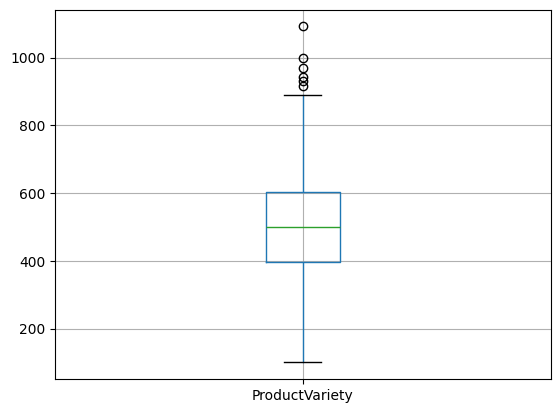

In [5]:
boxplot = data.boxplot(column=['ProductVariety'])
plt.show()

In [6]:
print("Total Outlier: ", findOutlierInPercentage(data['ProductVariety']), '%')

Total Outlier:  0.36363636363636365 %


Terlihat bahwa nilai outlier dari column 'ProductVariety' kurang dari 5%, karena itu kita tidak akan menghapus nilai outlier

### 2. Marketing Spend

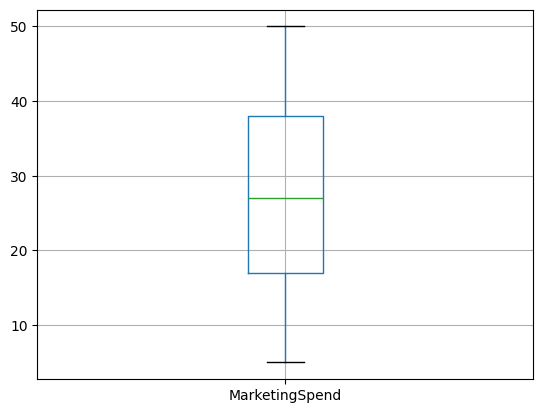

In [7]:
boxplot = data.boxplot(column=['MarketingSpend'])
plt.show()

Data sudah bersih

### 3. Customer Footfall

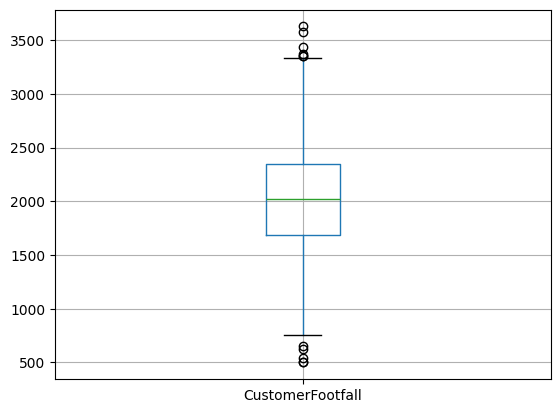

In [8]:
boxplot = data.boxplot(column=['CustomerFootfall'])
plt.show()

In [9]:
print("Total Outlier: ", findOutlierInPercentage(data['CustomerFootfall']), '%')

Total Outlier:  0.6666666666666667 %


Nilai dari column 'CustomerFootfall' dibawah 5% sehingga kita tidak akan menghapus column nya

### 4. StoreSize

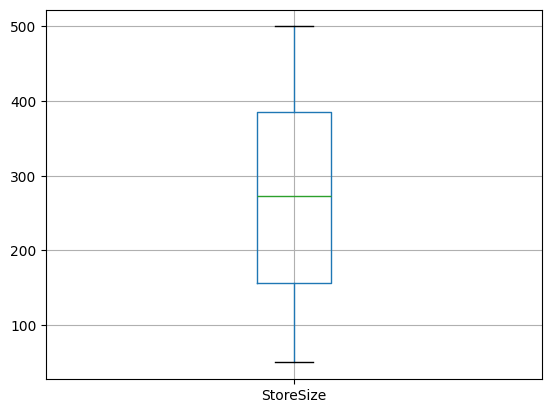

In [10]:
boxplot = data.boxplot(column=['StoreSize'])
plt.show()

Data sudah bersih

### 5. StoreAge

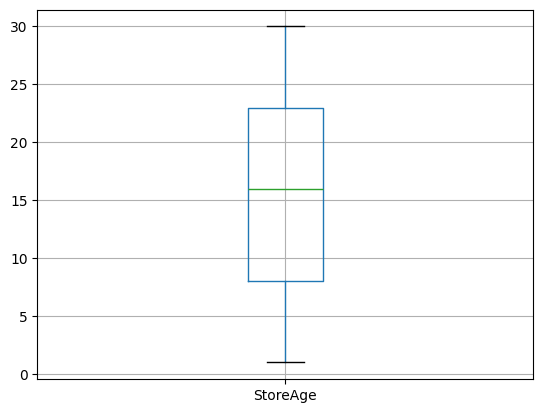

In [11]:
boxplot = data.boxplot(column=['StoreAge'])
plt.show()

Data sudah bersih

### 6. Competitor Distance

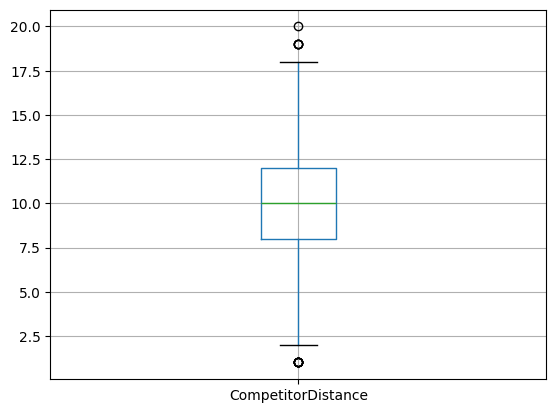

In [12]:
boxplot = data.boxplot(column=['CompetitorDistance'])
plt.show()

In [13]:
print("Total Outlier: ", findOutlierInPercentage(data['CompetitorDistance']), '%')

Total Outlier:  0.787878787878788 %


Total outlier kurang dari 5% sehingga kita tidak perlu menghapus column nya

### 7. Promotions Count

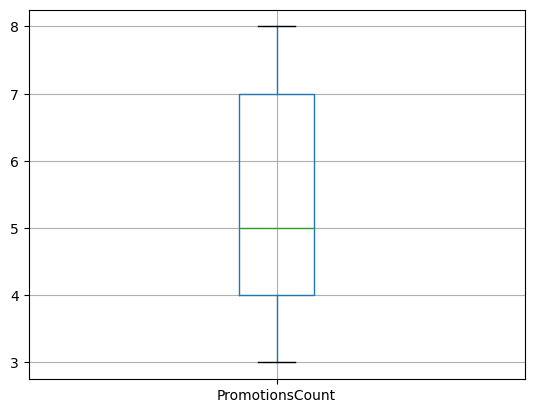

In [14]:
boxplot = data.boxplot(column=['PromotionsCount'])
plt.show()

Data sudah bersih

### 8. Economic Indicator

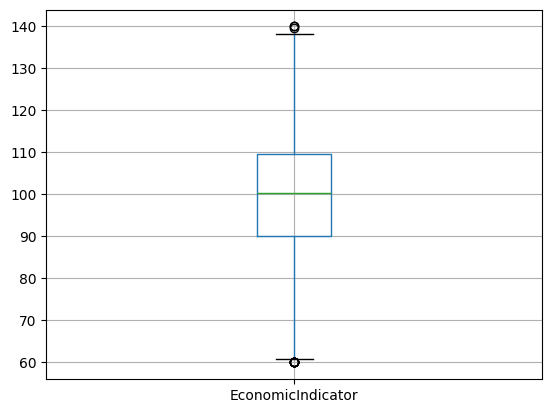

In [15]:
boxplot = data.boxplot(column=['EconomicIndicator'])
plt.show()

In [16]:
print("Total Outlier: ", findOutlierInPercentage(data['EconomicIndicator']), '%')

Total Outlier:  0.7272727272727273 %


Total dari outlier kurang dari 5%, jadi kita tidak perlu menghapus column nya

### 9. Monthly Sales Ravenue

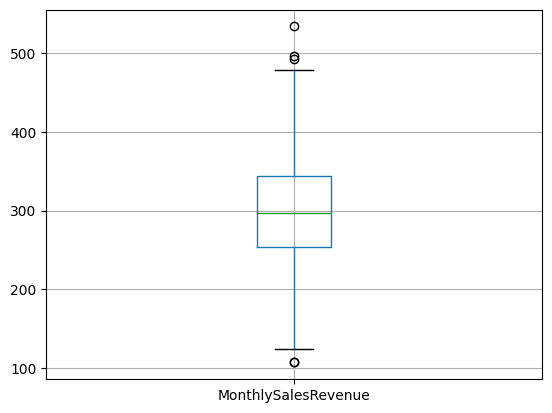

In [17]:
boxplot = data.boxplot(column=['MonthlySalesRevenue'])
plt.show()

In [18]:
print("Total Outlier: ", findOutlierInPercentage(data['MonthlySalesRevenue']), '%')

Total Outlier:  0.30303030303030304 %


Total dari outlier kurang dari 5%, sehingga kita tidak perlu menghapus column nya

### 10. Employee Efficiency

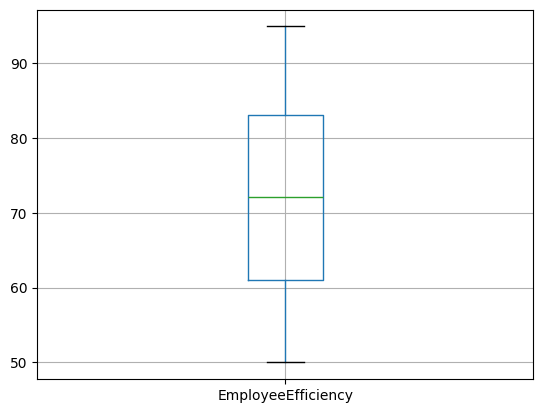

In [19]:
boxplot = data.boxplot(column=['EmployeeEfficiency'])
plt.show()

Data sudah bersih

# Membuat Model

In [49]:
data_encoded = pd.get_dummies(data, columns=['StoreLocation', 'StoreCategory'], drop_first=True) # -> memecah column StoreLocation dan StoreCategory menjadi column terpisah, karena data bersifat kategorikal

X = data_encoded.drop('MonthlySalesRevenue', axis=1) # -> Berisi nilai dari semua column kecuali 'MotnthlySalesRevenue', karena column ini adalah target column kita
y = data_encoded['MonthlySalesRevenue'] #-> mengambil column 'MonthlySalesRevenue'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # -> split data training

## Random Forest Regressor

 R²: 0.782625003225964
 MSE: 985.4240106844544
 MAE: 26.046326969696967
 RSE: 32.13018773014235


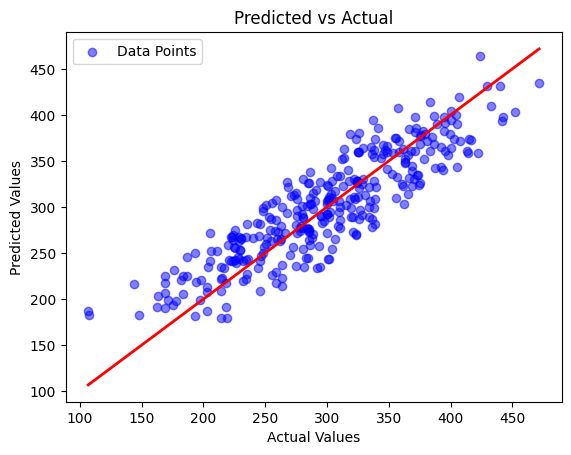

In [46]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rse = np.sqrt(np.sum((y_test - y_pred) ** 2) / (len(y_test) - X_test.shape[1] - 1))

print(f' R²: {r2}\n MSE: {mse}\n MAE: {mae}\n RSE: {rse}')
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')

x_line = np.linspace(min(y_test), max(y_test), 100) 
plt.plot(x_line, x_line, color='red', linestyle='-', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual')
plt.legend()

plt.show()

**R^2:**

Nilai 0.782, yang menunjukan bahwa model ini dapat menjelaskan sekitar **78.2%** variasi data, dan sisanya 21.8% tidak bisa dijelaskan oleh model.

**MSE (Mean Squared Error):**

Nilai dari MSE menunjukan **985.424**, yang merupakan hasil dari rata rata kuadrat, dari selisih antara niali prediksi dan nilai aktual

**MAE (Mean Absolute Error):**

Nilai MAE adalah **26.04**, yang menunjukan rata rata kesalahan absolute

**RSE (Residual Standard Error):**

Nilai RSE adalah **32.13**, yang menunjukan rata rata residual

Penyebaran titik biru cenderung dekat dengan garis merah yang menunjukan model sudah bisa memprediksi dengan akurat. Namun ada penyebaran yang tidak rata dibagian **150-200** dan **400** ke-atas, yang berarti model belum bisa memprediksi dengan baik di di area itu

## Decision Tree

 R²: 0.5671254056847712
 MSE: 1962.346291818182
 MAE: 36.33730303030303
 RSE: 45.34083538415821


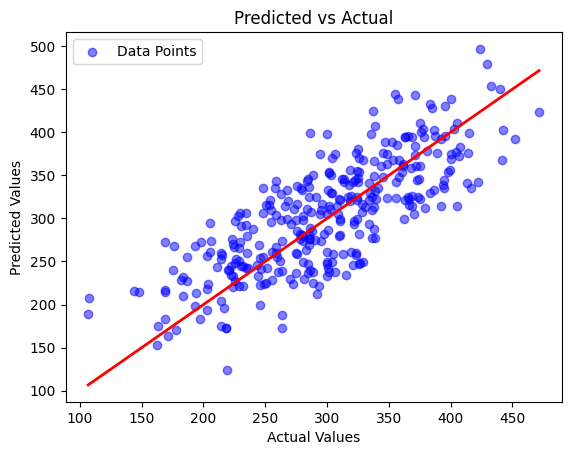

In [45]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rse = np.sqrt(np.sum((y_test - y_pred) ** 2) / (len(y_test) - X_test.shape[1] - 1))

print(f' R²: {r2}\n MSE: {mse}\n MAE: {mae}\n RSE: {rse}')
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')

x_line = np.linspace(min(y_test), max(y_test), 100) 
plt.plot(x_line, x_line, color='red', linestyle='-', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual')
plt.legend()

plt.show()

**R^2:**

Nilai 0.567, yang menunjukan bahwa model ini dapat menjelaskan sekitar **56.7%** variasi data, dan sisanya 43.3% tidak bisa dijelaskan oleh model.

**MSE (Mean Squared Error):**

Nilai dari MSE menunjukan **1962.346**, yang merupakan hasil dari rata rata kuadrat, dari selisih antara niali prediksi dan nilai aktual

**MAE (Mean Absolute Error):**

Nilai MAE adalah **36.33**, yang menunjukan rata rata kesalahan absolute

**RSE (Residual Standard Error):**

Nilai RSE adalah **45.34**, yang menunjukan rata rata residual

Penyebaran dari titik biru terlihat cenderung jauh dari garis merah, yang berarti model ini sering memprediksi nilai yang berbeda dengan nilai aktual

## Linear Regression

 R²: 0.8129721784426359
 MSE: 847.851449172041
 MAE: 24.911429505825755
 RSE: 29.803109363018535


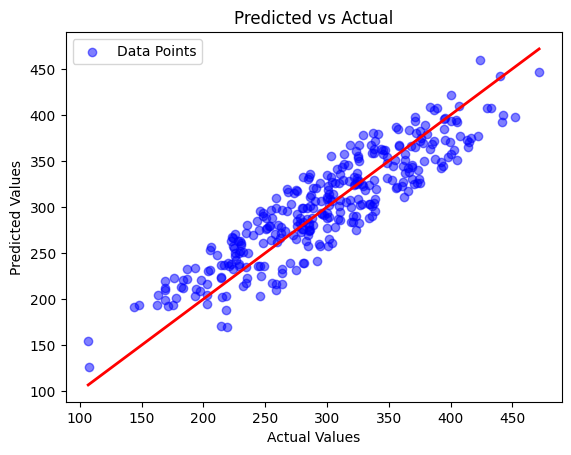

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rse = np.sqrt(np.sum((y_test - y_pred) ** 2) / (len(y_test) - X_test.shape[1] - 1))

print(f' R²: {r2}\n MSE: {mse}\n MAE: {mae}\n RSE: {rse}')
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')

x_line = np.linspace(min(y_test), max(y_test), 100) 
plt.plot(x_line, x_line, color='red', linestyle='-', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual')
plt.legend()

plt.show()


**R^2:**

Nilai 0.8129, yang menunjukan bahwa model ini dapat menjelaskan sekitar **81.3%** variasi data, dan sisanya 19.7% tidak bisa dijelaskan oleh model.

**MSE (Mean Squared Error):**

Nilai dari MSE menunjukan **847.85**, yang merupakan hasil dari rata rata kuadrat, dari selisih antara niali prediksi dan nilai aktual

**MAE (Mean Absolute Error):**

Nilai MAE adalah **24.911**, yang menunjukan rata rata kesalahan absolute

**RSE (Residual Standard Error):**

Nilai RSE adalah **29.8031**, yang menunjukan rata rata residual

Penyebaran titik biru mengikuti pola dari garis diagonal dari kiri bawah ke kanan atas, menunjukan bahwa model sudah cukup baik dalam memprediksi data, namun ada penyimpangan di nilai rendah yang < 200 dan > 400. Hal ini menunjukan bahwa model ini kurang akurat untuk nilai yang berada di ujung ekstrem

## Lasso Regression

 R²: 0.8128099837348847
 MSE: 848.5867249019825
 MAE: 24.910551755143874
 RSE: 29.816029523797795


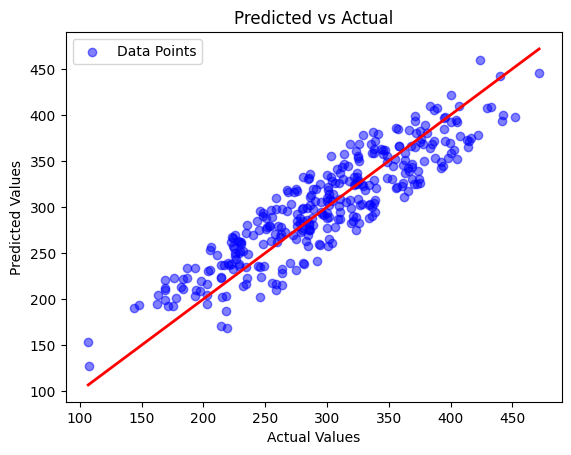

In [47]:
model = Lasso(alpha=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rse = np.sqrt(np.sum((y_test - y_pred) ** 2) / (len(y_test) - X_test.shape[1] - 1))

print(f' R²: {r2}\n MSE: {mse}\n MAE: {mae}\n RSE: {rse}')
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')

x_line = np.linspace(min(y_test), max(y_test), 100) 
plt.plot(x_line, x_line, color='red', linestyle='-', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual')
plt.legend()

plt.show()

**R^2:**

Nilai 0.8128, yang menunjukan bahwa model ini dapat menjelaskan sekitar **81.3%** variasi data, dan sisanya 19.7% tidak bisa dijelaskan oleh model.

**MSE (Mean Squared Error):**

Nilai dari MSE menunjukan **848.586**, yang merupakan hasil dari rata rata kuadrat, dari selisih antara niali prediksi dan nilai aktual

**MAE (Mean Absolute Error):**

Nilai MAE adalah **24.9105**, yang menunjukan rata rata kesalahan absolute

**RSE (Residual Standard Error):**

Nilai RSE adalah **29.81602**, yang menunjukan rata rata residual

Penyebaran titik biru mengikuti pola dari garis diagonal dari kiri bawah ke kanan atas, menunjukan bahwa model sudah cukup baik dalam memprediksi data, namun ada penyimpangan di nilai rendah yang < 200 dan > 400. Hal ini menunjukan bahwa model ini kurang akurat untuk nilai yang berada di ujung ekstrem

## Bayesain Regression

 R²: 0.8132329601726587
 MSE: 846.6692498293105
 MAE: 24.887338220986166
 RSE: 29.782324173148673


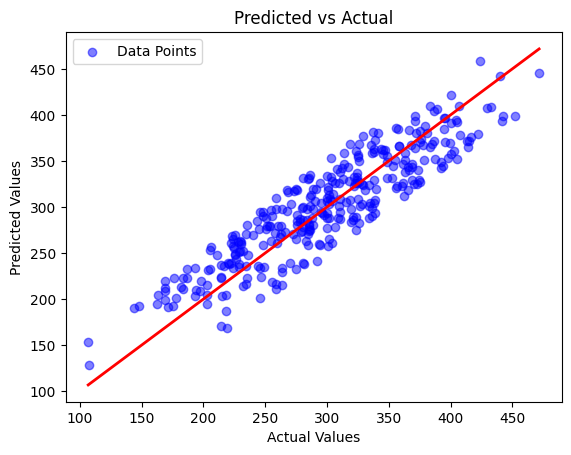

In [48]:
model = BayesianRidge()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rse = np.sqrt(np.sum((y_test - y_pred) ** 2) / (len(y_test) - X_test.shape[1] - 1))

print(f' R²: {r2}\n MSE: {mse}\n MAE: {mae}\n RSE: {rse}')
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')

x_line = np.linspace(min(y_test), max(y_test), 100) 
plt.plot(x_line, x_line, color='red', linestyle='-', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual')
plt.legend()

plt.show()

**R^2:**

Nilai 0.8132, yang menunjukan bahwa model ini dapat menjelaskan sekitar **81.3%** variasi data, dan sisanya 19.7% tidak bisa dijelaskan oleh model.

**MSE (Mean Squared Error):**

Nilai dari MSE menunjukan **846.669**, yang merupakan hasil dari rata rata kuadrat, dari selisih antara niali prediksi dan nilai aktual

**MAE (Mean Absolute Error):**

Nilai MAE adalah **24.887**, yang menunjukan rata rata kesalahan absolute

**RSE (Residual Standard Error):**

Nilai RSE adalah **29.7823**, yang menunjukan rata rata residual

Penyebaran titik biru mengikuti pola dari garis diagonal dari kiri bawah ke kanan atas, menunjukan bahwa model sudah cukup baik dalam memprediksi data, namun ada penyimpangan di nilai rendah yang < 200 dan > 400. Hal ini menunjukan bahwa model ini kurang akurat untuk nilai yang berada di ujung ekstrem

# Analisis Kesalahan


Hasil Model:
                     Model          MSE        MAE        RSE         R²  \
0         Lasso Regression   848.586725  24.910552  29.816030  81.280998   
1      Bayesian Regression   846.669250  24.887338  29.782324  81.323296   
2        Linear Regression   847.851449  24.911430  29.803109  81.297218   
3            Decision Tree  1962.346292  36.337303  45.340835  56.712541   
4  Random Forest Regresson   985.424011  26.046327  32.130188  78.262500   

    MAPE (%)  
0   9.042403  
1   9.033880  
2   9.041185  
3  13.253674  
4   9.610468  


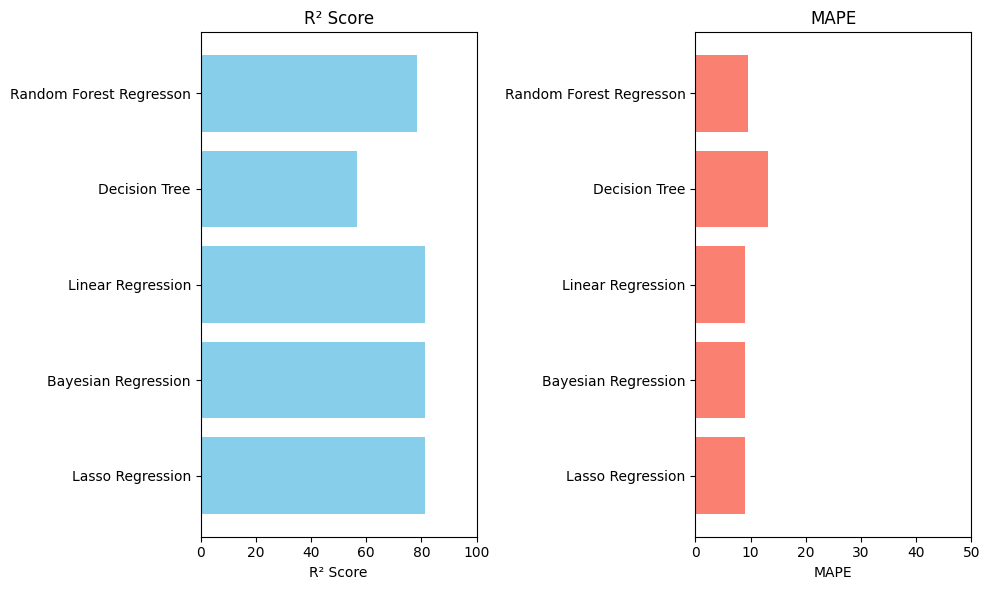

In [43]:
models = {
    "Lasso Regression": Lasso(alpha=0.1, random_state=42),
    "Bayesian Regression": BayesianRidge(),
    "Linear Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest Regresson" : RandomForestRegressor(random_state=42)
}

results = []

# Bikin model ulang
for name, model in models.items():
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred) * 100
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rse = np.sqrt(np.sum((y_test - y_pred) ** 2) / (len(y_test) - X_test.shape[1] - 1))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100 # -> konversi ke persen
    
    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RSE" : rse,
        "R²": r2,
        "MAPE (%)": mape,
    })

results_df = pd.DataFrame(results)
print("\nHasil Model:")
print(results_df)

plt.figure(figsize=(10, 6))

# Bar plot untuk R²
plt.subplot(1, 2, 1)
plt.barh(results_df['Model'], results_df['R²'], color='skyblue')
plt.title('R² Score')
plt.xlabel('R² Score')
plt.xlim(0, 100)

# Bar plot untuk MAPE
plt.subplot(1, 2, 2)
plt.barh(results_df['Model'], results_df['MAPE (%)'], color='salmon')
plt.title('MAPE')
plt.xlabel('MAPE')
plt.xlim(0, 50) 

plt.tight_layout()
plt.show()

Dari grafik diatas terlihat bahwa ada dua pengukuran yang digunakan untk mengukur akurasi dari ke-lima model ini, yaitu R² dan MAPE (Mean Absolute Percentage Error). R^2 adalah parameter dimana menjelaskan berapa persen model bisa menjelaskan data-nya, yang artinya semakin besar nilai R² semakin bagus. Pengukurang ke-dua adalah MAPE, dimana MAPE menunjukan kesalahan rata-rata dalam bentuk persentase, yang artinya semakin kecil nilai MAPE, semakin bagus. 

Dari grafik diatas terlihat bahwa model yang paling jelek adalah model dari 'Decision Tree', dan model yang paling bagus adalah model dari **Bayesian Regression** dimana model Lasso memiliki nilai MAPE senilai **9.033%**, yang berarti prediksi rata-rata meleset 9.033% dari nilai aslinya, dan untuk pengukuran R², model yang paling bagus adalah model **Bayesian Regression**, dimana memiliki nilai R² senilai **81.323**, yang berarti model Bayesian mampu menjelaskan sekitar 81% dari data yang ada

# Analisis

**1. Bayesian Regression:**
Model ini bisa menjadi model yang paling baik karena model ini bisa menggunakan prior dan likelihood sebagai cara untuk mengatasi ketidakpastian data dan paremeter, sehingga bisa memberikan data yang lebih stabil. 

**2. Linear Regression:**
Linear regression lebih cocok digunakan dalam model yang memiliki hubungan yang linear, dimana X mempengaruhi Y, data yang dipakai saat ini kebetulan beisi data yang linear

**3. Lasso Regression:**
Lasso Regression menggunakan regularisasi L1, dimana regularisasi ini berguna untuk mengurangi kesalahan yang disebabkan oleh overfitting dengan cara menerapkan penalti. Namun dalam data set ini kemungkinan regularisasi L1 ini membatasi akurasi

**4. Random Forest Regression:**
Random forest biasa digunakan dalam model yang bersifat non-linear, namun pada data set ini hubungan yang terjadi condong ke arah dominan sehingga, model Random Forest kurang cocok dalam hal ini

**5. Decision Tree:**
Decision tree bekerja dengan cara membagi data menjadi potongan yang kecil dan menglompokan nya ke dalam kelompok kelompok yang lebih kecil. Model ini kurang cocok di data ini karena Decision Tree ini sering terjadi overfitting dimana hasil dari model hanya bagus di data training